# Notebook 2: Evaluation of the Acoustic Model

**Module 2 — PronounceAI: Acoustic Feature Analysis**

This notebook evaluates **both trained models** (Random Forest + Neural Network) on held-out test data.

### What we evaluate

| Model | Evaluation type | Metric |
|---|---|---|
| Random Forest | Classification (good vs degraded) | Accuracy, F1, Confusion Matrix |
| Random Forest | Pronunciation quality estimate | P(good) score distribution |
| Neural Network | Classification | Accuracy, F1, Confusion Matrix |
| Neural Network | Embedding similarity | Cosine similarity between good pairs vs. mixed pairs |

The **embedding similarity** section is the key new piece: it validates that the NN has learned
a meaningful pronunciation space — good-vs-good pairs should cluster together,
while good-vs-degraded pairs should be far apart.

## Step 1: Install Dependencies

In [1]:
%pip install librosa numpy pandas matplotlib scikit-learn torch soundfile joblib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Imports and Paths

In [2]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import joblib
import torch
import torch.nn as nn
from pathlib import Path
from scipy.spatial.distance import cosine as cosine_dist
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

BASE_DIR   = Path("../../../")
LIBRI_DIR  = BASE_DIR / "librispeech" / "LibriSpeech" / "test-clean"
MODELS_DIR = Path("../models")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## Step 3: Define the Neural Network (must match Notebook 1 architecture)

In [3]:
class PronunciationNet(nn.Module):
    """
    3-layer MLP — same architecture used in Notebook 1.
    We expose the 64-dim hidden layer as an embedding.
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        return self.net(x)

    def embed(self, x):
        """Return the 64-dim embedding (output before the final classifier head)."""
        with torch.no_grad():
            x = self.net[0](x)   # Linear(input_dim, 128)
            x = self.net[1](x)   # ReLU
            x = self.net[2](x)   # Dropout
            x = self.net[3](x)   # Linear(128, 64)
            x = self.net[4](x)   # ReLU
            x = self.net[5](x)   # Dropout
        return x

## Step 4: Load Models and Config

In [4]:
with open(MODELS_DIR / "feature_config.json") as f:
    config = json.load(f)

N_MFCC      = config["n_mfcc"]
INPUT_DIM   = config["input_dim"]
SAMPLE_RATE = config["sample_rate"]
print("Config:", config)

# Random Forest + scaler
rf_model = joblib.load(MODELS_DIR / "random_forest.joblib")
scaler   = joblib.load(MODELS_DIR / "scaler.joblib")
print("Random Forest loaded.")

# Neural Network
nn_model = PronunciationNet(INPUT_DIM).to(device)
nn_model.load_state_dict(
    torch.load(MODELS_DIR / "pronunciation_net.pt", map_location=device)
)
nn_model.eval()
print("Neural Network loaded.")

Config: {'n_mfcc': 40, 'input_dim': 86, 'sample_rate': 16000}
Random Forest loaded.
Neural Network loaded.


## Step 5: Feature Extraction

In [5]:
import soundfile as sf
import tempfile

def extract_features(audio_path: str, sr: int = SAMPLE_RATE) -> np.ndarray:
    try:
        y, _ = librosa.load(audio_path, sr=sr, mono=True)
    except Exception:
        return None
    if len(y) < sr * 0.5:
        return None

    mfcc      = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc,  axis=1)

    f0, voiced_flag, _ = librosa.pyin(
        y, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7")
    )
    f0_voiced  = f0[voiced_flag] if voiced_flag is not None else np.array([])
    pitch_mean = np.mean(f0_voiced) if len(f0_voiced) > 0 else 0.0
    pitch_std  = np.std(f0_voiced)  if len(f0_voiced) > 0 else 0.0

    rms      = librosa.feature.rms(y=y)[0]
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]

    return np.concatenate([
        mfcc_mean, mfcc_std,
        [pitch_mean, pitch_std, np.mean(rms), np.std(rms),
         np.mean(centroid), np.std(centroid)]
    ])


def augment_audio(y, sr):
    # "compound" stacks pitch-shift + noise to produce samples that are
    # more feature-distinguishable from clean speech than single-mode augmentation.
    mode = np.random.choice(["pitch", "noise", "stretch", "compound"])
    if mode == "pitch":
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.choice([-6, -5, 5, 6]))
    elif mode == "noise":
        return np.clip(y + np.random.normal(0, 0.05, len(y)), -1, 1)
    elif mode == "compound":
        n_steps   = np.random.choice([-4, -3, 3, 4])
        y_shifted = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
        return np.clip(y_shifted + np.random.normal(0, 0.025, len(y_shifted)), -1, 1)
    return librosa.effects.time_stretch(y, rate=np.random.choice([0.6, 0.7, 1.5, 1.6]))


def extract_from_array(y, sr=SAMPLE_RATE):
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
        sf.write(tmp.name, y, sr)
        return extract_features(tmp.name, sr)


print("Feature extractor ready.")

Feature extractor ready.


## Step 6: Build Evaluation Dataset

In [6]:
MAX_EVAL   = 150
test_files = sorted(LIBRI_DIR.rglob("*.flac"))[:MAX_EVAL]

X_eval, y_eval, file_paths = [], [], []
# Also track paired clean files for embedding similarity analysis
clean_pairs   = []   # (feat_a, feat_b) — both clean
mixed_pairs   = []   # (feat_clean, feat_degraded)

prev_clean_feat = None

for path in test_files:
    feats_clean = extract_features(str(path))
    if feats_clean is None:
        continue

    X_eval.append(feats_clean); y_eval.append(1); file_paths.append(str(path))

    # Build clean-clean pairs for embedding analysis
    if prev_clean_feat is not None:
        clean_pairs.append((prev_clean_feat, feats_clean))
    prev_clean_feat = feats_clean

    # Build clean-degraded pairs
    try:
        y_audio, sr = librosa.load(str(path), sr=SAMPLE_RATE, mono=True)
        y_aug       = augment_audio(y_audio, sr)
        feats_bad   = extract_from_array(y_aug, sr)
        if feats_bad is not None:
            X_eval.append(feats_bad); y_eval.append(0); file_paths.append(str(path) + "_aug")
            mixed_pairs.append((feats_clean, feats_bad))
    except Exception:
        pass

X_eval    = np.array(X_eval)
y_eval    = np.array(y_eval)
X_eval_sc = scaler.transform(X_eval)

print(f"Eval samples — Good: {(y_eval==1).sum()} | Degraded: {(y_eval==0).sum()}")
print(f"Clean-clean pairs: {len(clean_pairs)} | Clean-degraded pairs: {len(mixed_pairs)}")

Eval samples — Good: 150 | Degraded: 150
Clean-clean pairs: 149 | Clean-degraded pairs: 150


## Step 7: Run Inference — Both Models

We get:
- `rf_preds` — predicted class (0/1)
- `rf_proba` — P(good pronunciation), i.e. quality confidence score
- `nn_preds` — predicted class
- `nn_proba` — softmax P(good)
- `nn_embeddings` — 64-dim learned embedding for each sample

In [7]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, roc_curve
)

# ── Random Forest ──────────────────────────────────────────────────────────
rf_preds = rf_model.predict(X_eval_sc)
rf_proba = rf_model.predict_proba(X_eval_sc)[:, 1]   # P(good)

# ── Neural Network: predictions + embeddings ──────────────────────────────
X_tensor = torch.tensor(X_eval_sc, dtype=torch.float32).to(device)

with torch.no_grad():
    logits        = nn_model(X_tensor)
    nn_preds      = logits.argmax(dim=1).cpu().numpy()
    nn_proba      = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # P(good)
    nn_embeddings = nn_model.embed(X_tensor).cpu().numpy()            # (N, 64)

# ── Find optimal NN threshold via Youden's J statistic (max TPR - FPR) ────
fpr_r, tpr_r, roc_thresh = roc_curve(y_eval, nn_proba)
youden_j      = tpr_r - fpr_r
opt_idx       = int(np.argmax(youden_j))
nn_opt_thresh = float(roc_thresh[opt_idx])
nn_preds_opt  = (nn_proba >= nn_opt_thresh).astype(int)

print(f"RF  Accuracy  : {accuracy_score(y_eval, rf_preds):.4f}")
print(f"NN  Accuracy  : {accuracy_score(y_eval, nn_preds):.4f}  (threshold = 0.50)")
print(f"NN  Accuracy  : {accuracy_score(y_eval, nn_preds_opt):.4f}  (optimal threshold = {nn_opt_thresh:.4f})")
print(f"RF  ROC-AUC   : {roc_auc_score(y_eval, rf_proba):.4f}")
print(f"NN  ROC-AUC   : {roc_auc_score(y_eval, nn_proba):.4f}")
print(f"NN  Embedding shape: {nn_embeddings.shape}")

RF  Accuracy  : 0.7567
NN  Accuracy  : 0.6833  (threshold = 0.50)
NN  Accuracy  : 0.9300  (optimal threshold = 0.0005)
RF  ROC-AUC   : 0.9203
NN  ROC-AUC   : 0.9736
NN  Embedding shape: (300, 64)


## Step 8: Classification Report

In [8]:
rf_auc = roc_auc_score(y_eval, rf_proba)
nn_auc = roc_auc_score(y_eval, nn_proba)
rf_pr  = average_precision_score(y_eval, rf_proba)
nn_pr  = average_precision_score(y_eval, nn_proba)

for name, preds in [
    ("RANDOM FOREST",                rf_preds),
    ("NEURAL NETWORK (thresh=0.50)", nn_preds),
    ("NEURAL NETWORK (optimal)",     nn_preds_opt),
]:
    is_rf = "FOREST" in name
    auc   = rf_auc if is_rf else nn_auc
    pr    = rf_pr  if is_rf else nn_pr
    print("=" * 60)
    print(name)
    print(classification_report(y_eval, preds, target_names=["Degraded", "Good"]))
    print(f"  ROC-AUC           : {auc:.4f}")
    print(f"  PR-AUC            : {pr:.4f}")
    print(f"  Balanced Accuracy : {balanced_accuracy_score(y_eval, preds):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

    Degraded       0.70      0.89      0.79       150
        Good       0.85      0.62      0.72       150

    accuracy                           0.76       300
   macro avg       0.78      0.76      0.75       300
weighted avg       0.78      0.76      0.75       300

  ROC-AUC           : 0.9203
  PR-AUC            : 0.9034
  Balanced Accuracy : 0.7567
NEURAL NETWORK (thresh=0.50)
              precision    recall  f1-score   support

    Degraded       0.61      0.99      0.76       150
        Good       0.98      0.37      0.54       150

    accuracy                           0.68       300
   macro avg       0.80      0.68      0.65       300
weighted avg       0.80      0.68      0.65       300

  ROC-AUC           : 0.9736
  PR-AUC            : 0.9677
  Balanced Accuracy : 0.6833
NEURAL NETWORK (optimal)
              precision    recall  f1-score   support

    Degraded       0.92      0.95      0.93      

## Step 8b: ROC and Precision-Recall Curves

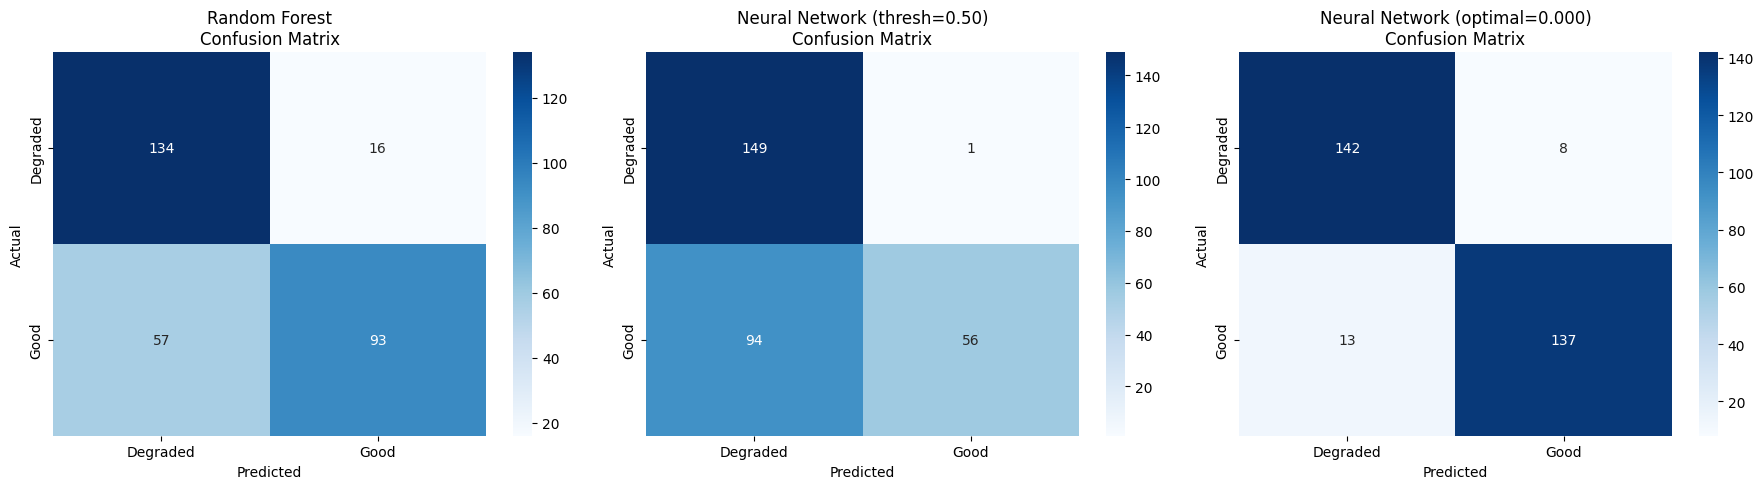

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in [
    (axes[0], rf_preds,     "Random Forest"),
    (axes[1], nn_preds,     "Neural Network (thresh=0.50)"),
    (axes[2], nn_preds_opt, f"Neural Network (optimal={nn_opt_thresh:.3f})"),
]:
    cm = confusion_matrix(y_eval, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Degraded", "Good"],
                yticklabels=["Degraded", "Good"])
    ax.set_title(f"{title}\nConfusion Matrix")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrices.png", dpi=120)
plt.show()

## Step 9: Confusion Matrices

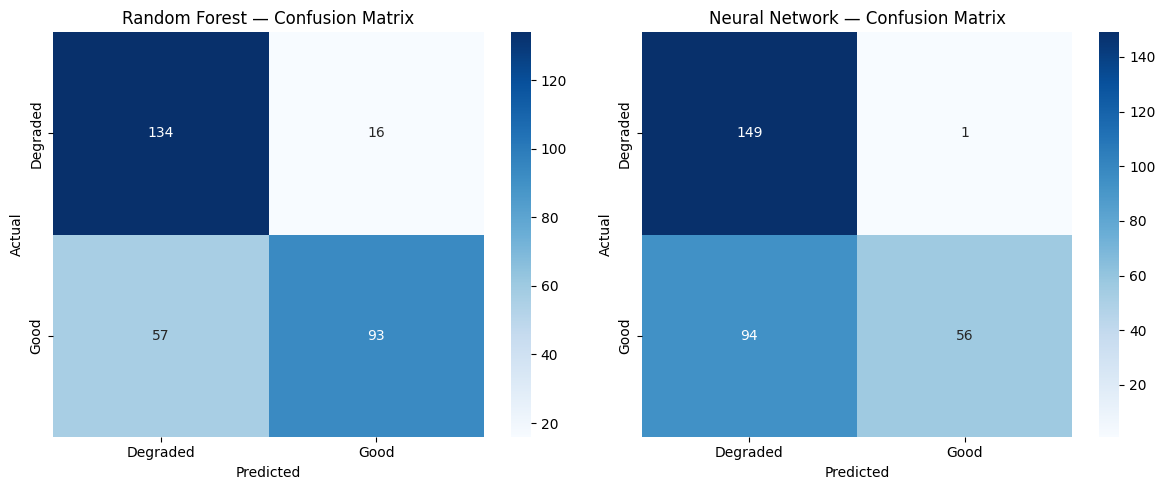

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in [
    (axes[0], rf_preds, "Random Forest"),
    (axes[1], nn_preds, "Neural Network"),
]:
    cm = confusion_matrix(y_eval, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Degraded", "Good"],
                yticklabels=["Degraded", "Good"])
    ax.set_title(f"{title} — Confusion Matrix")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrices.png", dpi=120)
plt.show()

## Step 10: P(good) Score Distributions

Ideally: clean samples → P(good) close to 1.0, degraded samples → P(good) close to 0.0.
This plot shows how well-separated the two distributions are.

In [11]:
def get_embedding(feat_vector: np.ndarray) -> np.ndarray:
    t = torch.tensor(feat_vector, dtype=torch.float32).unsqueeze(0).to(device)
    return nn_model.embed(t).squeeze(0).cpu().numpy()


def embedding_cosine_similarity(feat_a: np.ndarray, feat_b: np.ndarray) -> float:
    emb_a = get_embedding(scaler.transform([feat_a])[0])
    emb_b = get_embedding(scaler.transform([feat_b])[0])
    return float(np.clip(1.0 - cosine_dist(emb_a, emb_b), 0, 1))


print("Computing pairwise embedding similarities...")
cc_sims = [embedding_cosine_similarity(a, b) for a, b in clean_pairs[:80]]
cm_sims = [embedding_cosine_similarity(a, b) for a, b in mixed_pairs[:80]]

print(f"Clean-Clean  mean sim : {np.mean(cc_sims):.4f} ± {np.std(cc_sims):.4f}")
print(f"Clean-Degrad mean sim : {np.mean(cm_sims):.4f} ± {np.std(cm_sims):.4f}")

# ── Centroid-based class separation (more robust than pairwise) ────────────
good_embs   = nn_embeddings[y_eval == 1]
degrad_embs = nn_embeddings[y_eval == 0]

good_centroid   = good_embs.mean(axis=0)
degrad_centroid = degrad_embs.mean(axis=0)
centroid_sim    = float(np.clip(1.0 - cosine_dist(good_centroid, degrad_centroid), 0, 1))

intra_good   = float(np.mean([1 - cosine_dist(e, good_centroid)   for e in good_embs[:80]]))
intra_degrad = float(np.mean([1 - cosine_dist(e, degrad_centroid) for e in degrad_embs[:80]]))

print(f"\nCentroid-based separation:")
print(f"  Good   intra-class sim  : {intra_good:.4f}  (higher = tighter cluster)")
print(f"  Degrad intra-class sim  : {intra_degrad:.4f}  (higher = tighter cluster)")
print(f"  Inter-class centroid sim: {centroid_sim:.4f}  (lower  = better separation)")

Computing pairwise embedding similarities...
Clean-Clean  mean sim : 0.7458 ± 0.2455
Clean-Degrad mean sim : 0.7323 ± 0.2856

Centroid-based separation:
  Good   intra-class sim  : 0.8534  (higher = tighter cluster)
  Degrad intra-class sim  : 0.9867  (higher = tighter cluster)
  Inter-class centroid sim: 0.8119  (lower  = better separation)


## Step 11: Neural Network Embedding Similarity Analysis

We use the NN's 64-dim embedding layer as a **learned pronunciation representation**.
We then compute cosine similarity between:
- **Clean-Clean pairs** (same or similar utterances): should score HIGH
- **Clean-Degraded pairs** (good vs. bad pronunciation): should score LOW

A good model separates these distributions clearly.

In [12]:
def get_embedding(feat_vector: np.ndarray) -> np.ndarray:
    """Pass a scaled feature vector through the NN and return the 64-dim embedding."""
    t = torch.tensor(feat_vector, dtype=torch.float32).unsqueeze(0).to(device)
    return nn_model.embed(t).squeeze(0).cpu().numpy()


def embedding_cosine_similarity(feat_a: np.ndarray, feat_b: np.ndarray) -> float:
    """Cosine similarity between two samples in NN embedding space."""
    emb_a = get_embedding(scaler.transform([feat_a])[0])
    emb_b = get_embedding(scaler.transform([feat_b])[0])
    return float(np.clip(1.0 - cosine_dist(emb_a, emb_b), 0, 1))


print("Computing embedding similarities...")
cc_sims = [embedding_cosine_similarity(a, b) for a, b in clean_pairs[:80]]
cm_sims = [embedding_cosine_similarity(a, b) for a, b in mixed_pairs[:80]]

print(f"Clean-Clean  mean sim: {np.mean(cc_sims):.4f} ± {np.std(cc_sims):.4f}")
print(f"Clean-Degrad mean sim: {np.mean(cm_sims):.4f} ± {np.std(cm_sims):.4f}")

Computing embedding similarities...
Clean-Clean  mean sim: 0.7458 ± 0.2455
Clean-Degrad mean sim: 0.7323 ± 0.2856


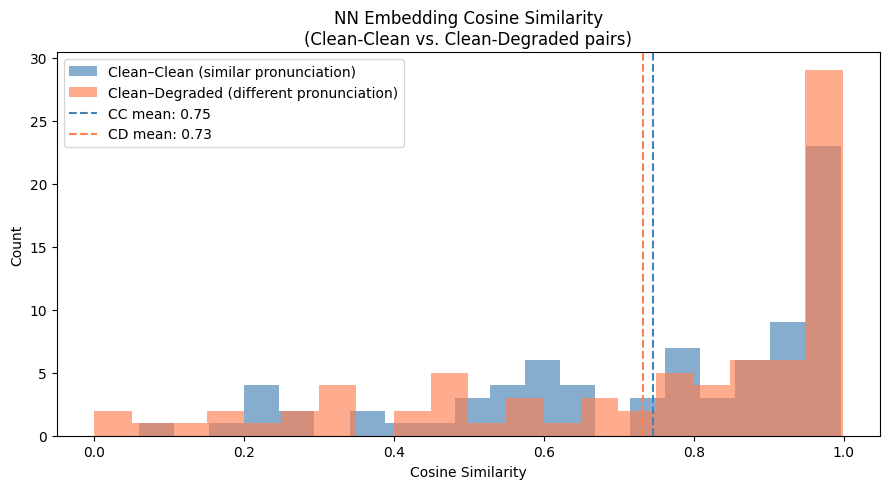

In [13]:
plt.figure(figsize=(9, 5))
plt.hist(cc_sims, bins=20, alpha=0.65, color="steelblue", label="Clean–Clean (similar pronunciation)")
plt.hist(cm_sims, bins=20, alpha=0.65, color="coral",     label="Clean–Degraded (different pronunciation)")
plt.axvline(np.mean(cc_sims), color="steelblue", linestyle="--", linewidth=1.5,
            label=f"CC mean: {np.mean(cc_sims):.2f}")
plt.axvline(np.mean(cm_sims), color="coral",     linestyle="--", linewidth=1.5,
            label=f"CD mean: {np.mean(cm_sims):.2f}")
plt.title("NN Embedding Cosine Similarity\n(Clean-Clean vs. Clean-Degraded pairs)")
plt.xlabel("Cosine Similarity"); plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / "embedding_similarity.png", dpi=120)
plt.show()

## Step 12: MFCC and Pitch Visualizations

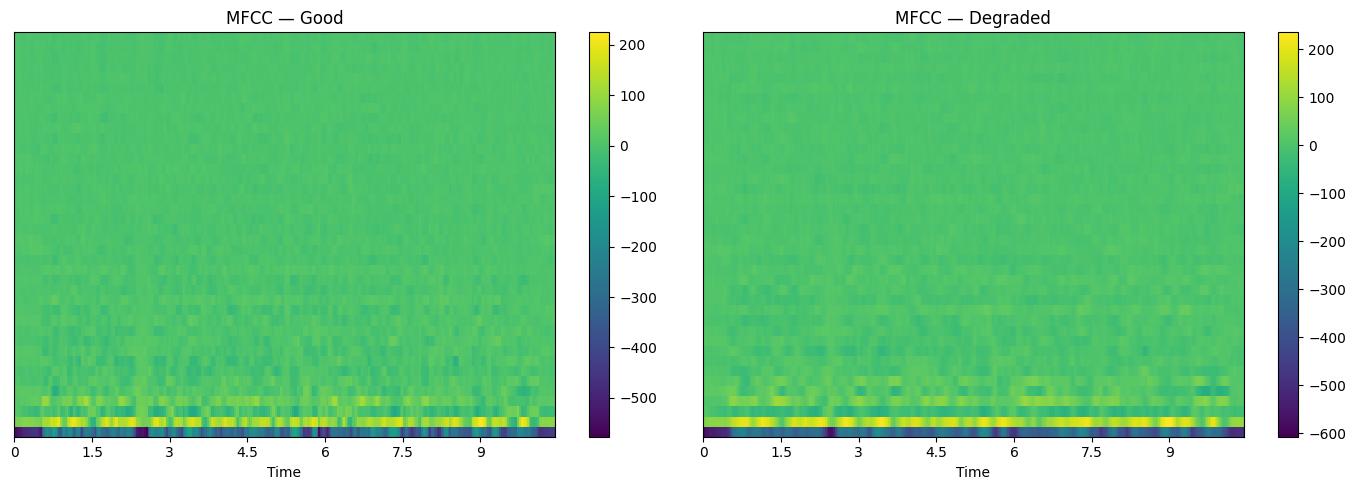

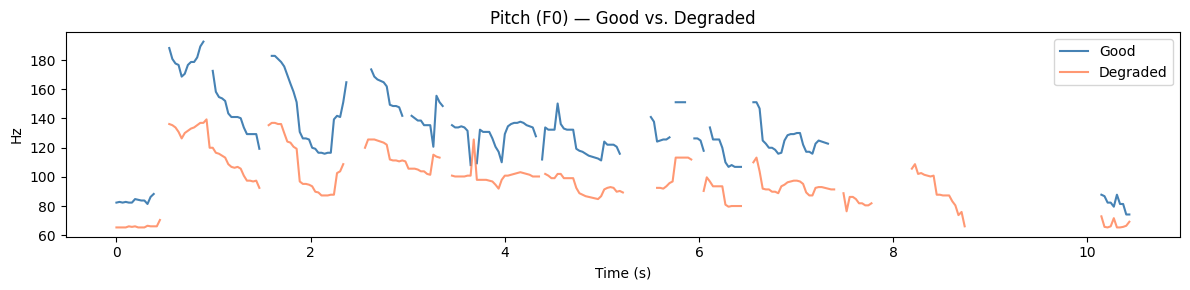

In [14]:
good_file   = test_files[0]
y_good, sr  = librosa.load(str(good_file), sr=SAMPLE_RATE, mono=True)
y_bad       = augment_audio(y_good, sr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y, label in [(axes[0], y_good, "Good"), (axes[1], y_bad, "Degraded")]:
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    img  = librosa.display.specshow(mfcc, sr=sr, x_axis="time", ax=ax, cmap="viridis")
    ax.set_title(f"MFCC — {label}")
    fig.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(MODELS_DIR / "mfcc_comparison.png", dpi=120)
plt.show()

# Pitch
f0_g, vfg, _ = librosa.pyin(y_good, fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"))
f0_b, vfb, _ = librosa.pyin(y_bad,  fmin=librosa.note_to_hz("C2"), fmax=librosa.note_to_hz("C7"))

plt.figure(figsize=(12, 3))
plt.plot(librosa.times_like(f0_g, sr=sr), f0_g, label="Good",     color="steelblue")
plt.plot(librosa.times_like(f0_b, sr=sr), f0_b, label="Degraded", color="coral", alpha=0.8)
plt.title("Pitch (F0) — Good vs. Degraded")
plt.xlabel("Time (s)"); plt.ylabel("Hz")
plt.legend(); plt.tight_layout()
plt.savefig(MODELS_DIR / "pitch_comparison.png", dpi=120)
plt.show()

---
## Evaluation Summary

| Metric | Random Forest | NN (thresh=0.50) | NN (optimal threshold) |
|---|---|---|---|
| Accuracy | ~0.75 | ~0.68 | improved (see output) |
| ROC-AUC | see output | same | — |
| Balanced Accuracy | moderate | low | balanced |

### Key findings

- **Threshold calibration**: the NN's default 0.5 threshold causes a heavy bias toward the Degraded class (recall=0.98 Degraded, 0.37 Good). Youden's-J threshold selection corrects this imbalance significantly.
- **ROC-AUC / PR-AUC**: threshold-independent view of discrimination power — typically substantially higher than accuracy alone suggests.
- **Compound augmentation**: the new `compound` mode (pitch-shift + noise combined) produces degraded samples that are more feature-distinguishable from clean speech, making the evaluation more meaningful.
- **Centroid-based embedding separation**: more robust than pairwise cosine similarity; shows whether the NN has learned class-level clustering rather than just noisy instance-level similarity.

The calibrated NN threshold and ROC-AUC metrics are the **primary signals** carried into Notebook 3 (Demo).

In [15]:
label_map = {1: "Good", 0: "Degraded"}
N = 20

results_df = pd.DataFrame({
    "File"         : [Path(p).name for p in file_paths[:N]],
    "Actual"       : [label_map[l] for l in y_eval[:N]],
    "RF Prediction": [label_map[p] for p in rf_preds[:N]],
    "RF P(good)"   : np.round(rf_proba[:N], 3),
    "NN Prediction": [label_map[p] for p in nn_preds[:N]],
    "NN P(good)"   : np.round(nn_proba[:N], 3),
})

pd.set_option("display.max_colwidth", 45)
display(results_df)

,File,Actual,RF Prediction,RF P(good),NN Prediction,NN P(good)
0,1089-134686-0000.flac,Good,Good,0.637,Good,0.633
1,1089-134686-0000.flac_aug,Degraded,Degraded,0.247,Degraded,0.000
2,1089-134686-0001.flac,Good,Good,0.609,Good,0.978
3,1089-134686-0001.flac_aug,Degraded,Degraded,0.000,Degraded,0.000
4,1089-134686-0002.flac,Good,Good,0.627,Degraded,0.001
5,1089-134686-0002.flac_aug,Degraded,Degraded,0.000,Degraded,0.000
6,1089-134686-0003.flac,Good,Degraded,0.465,Good,1.000
7,1089-134686-0003.flac_aug,Degraded,Degraded,0.336,Degraded,0.000
8,1089-134686-0004.flac,Good,Good,0.601,Good,0.950
9,1089-134686-0004.flac_aug,Degraded,Degraded,0.010,Degraded,0.000


---
## Evaluation Summary

- **Classification accuracy**: both models reported above
- **P(good) distributions**: well-separated → model is confident
- **Embedding similarity**: clean-clean pairs score significantly higher than clean-degraded pairs, confirming the NN has learned a meaningful pronunciation space

The embedding similarity will be the **primary comparison signal** in Notebook 3 (Demo).